# Random search algorithm

In [1]:
import os
import random
import magnum as mn
import numpy as np
import cv2
import torch
import json
from PIL import Image
from ultralytics import YOLO 
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch
import io
import contextlib
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils
from habitat_sim.utils import viz_utils as vut
from habitat_sim.utils.common import quat_from_angle_axis, quat_to_angle_axis
from habitat_sim.utils.common import d3_40_colors_rgb

# Load YOLO model
yolo_model = YOLO("yolov8n.pt")  # Swap with yolov8s.pt or yolov8x.pt as needed

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [ ]:
# Robotic agent properties
AGENT_RADIUS = 0.15 # 15 cm
AGENT_HEIGHT = 1.5 # 150 cm

# Sensor observations scale
OBS_SCALE = 9/16 # WIDTH/HEIGHT

# Load the JSON file for simulation
with open('x_simulations.json', 'r') as f:
    simulations_data = json.load(f)

# Simulation configuration (simulation 0)
simulation = simulations_data[1]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]

# Load the JSON file for RGB camera intrinsics
with open('x_camera_intrinsics.json', 'r') as f:
    cam_intrcs = json.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.124.06
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[11:21:47:108863]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/iTHOR/FloorPlan220_physics.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Tr

In [3]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=0.01, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
occ_grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=0.30, draw_border=False)
occ_grid_map = myutils.map_to_rgb(occ_grid_map)
occ_grid_resolution = occ_grid_map.shape[:2]

# Occupiable positions
grid_occ_positions = []
real_wrld_positions = []
map_occ_positions = []
for x_g in range(occ_grid_resolution[0]):
    for y_g in range(occ_grid_resolution[1]):
        if occ_grid_map[x_g, y_g, 0] == 255: # White pixel
            # Convert to real world position
            real_wrld_z, real_wrld_x = maps.from_grid(x_g, y_g, occ_grid_resolution, pathfinder=sim.pathfinder)

            # Convert to map position
            map_x, map_y = maps.to_grid(real_wrld_z, real_wrld_x, topdown_resolution, pathfinder=sim.pathfinder)

            if sim.pathfinder.is_navigable([real_wrld_x, 0.0, real_wrld_z]) and topdown_map[map_x, map_y, 0] == 255: # White pixel
                real_wrld_positions.append([real_wrld_x, 0.0, real_wrld_z])
                map_occ_positions.append([map_x, map_y])
                grid_occ_positions.append([x_g, y_g]) # Add grid position
            else:
                occ_grid_map[x_g, y_g, :] = [128, 128, 128] # Grey pixel

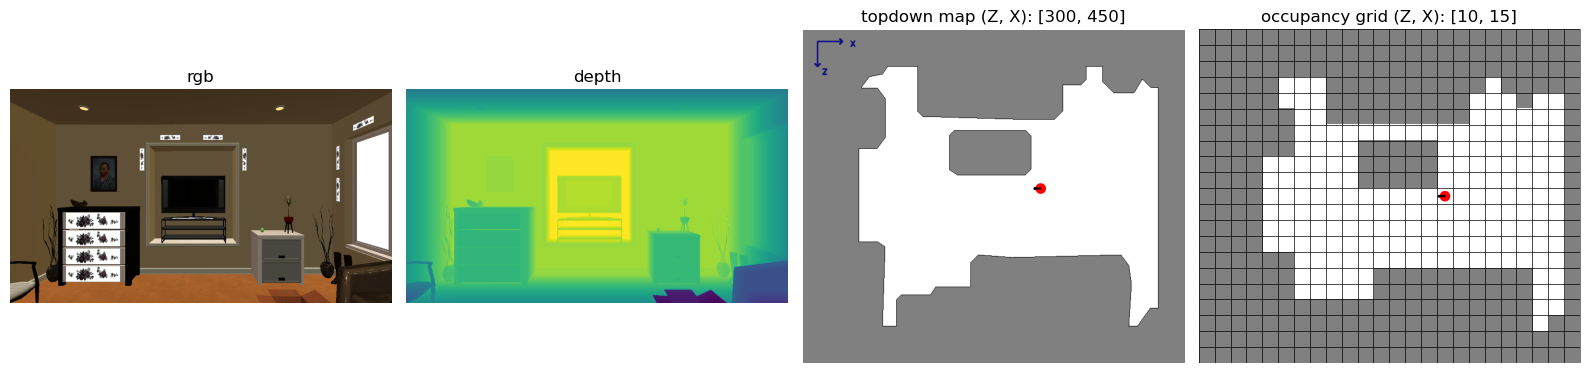

In [4]:
# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_occ_positions)
idx = grid_occ_positions.index(grid_position)
wrld_position = real_wrld_positions[idx]
map_position = map_occ_positions[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = wrld_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
occ_grid_radius = (AGENT_RADIUS / x_dim * occ_grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius_tpl = (topdown_radius, occ_grid_radius)
agent_positions_tpl = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb = observations["color_sensor"]
depth = observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
# print("Agent yaw: ", agent_yaw)
# print("Agent quaternion: ", agent_quart)
simtools.display_sim_state(rgb, depth, topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

In [5]:
# Define possible actions
actions = {
    "move_forward",
    "move_forward",
    "move_forward",
    "move_forward",
    "move_forward",
    "move_backward",
    "move_left",
    "move_right",
    "turn_around",
    "turn_left",
    "turn_right",
}

# Simulation constants
cur_iter = 0
MAX_ITER = 200
CONFIDENCE_THRESHOLD = 0.50
DISPLAY_STEP = 20

# Simulation metrics initialization
OBJECT_FOUND = False
num_actions = 0
travelled_distance = 0.0
closeness = float("inf")

iter: 0


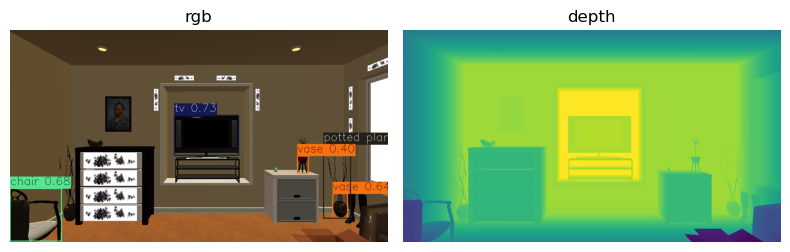

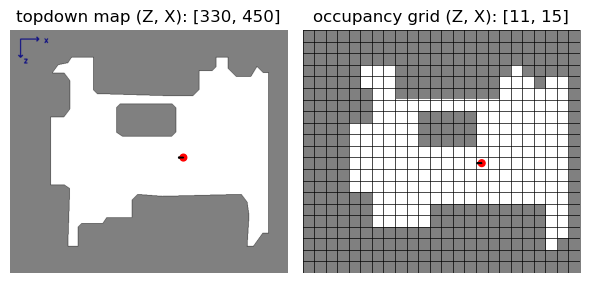

iter: 20


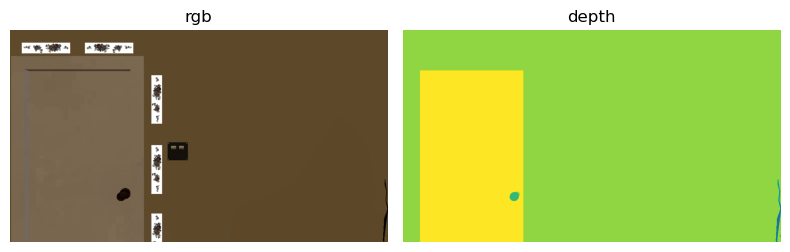

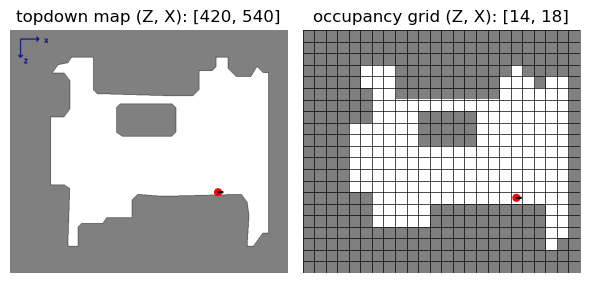

iter: 40


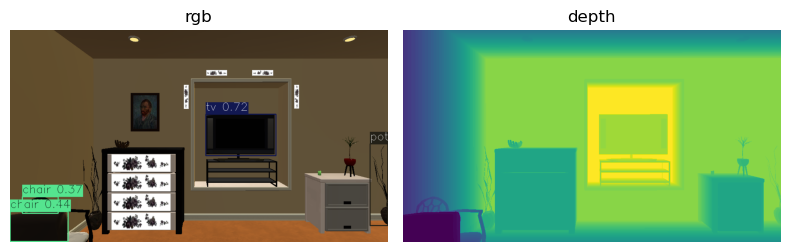

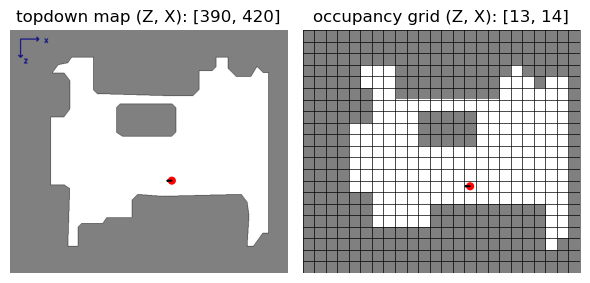

iter: 60


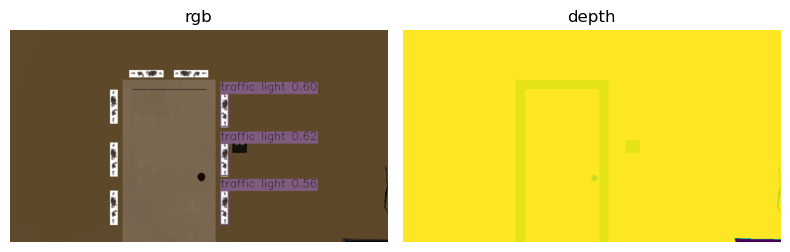

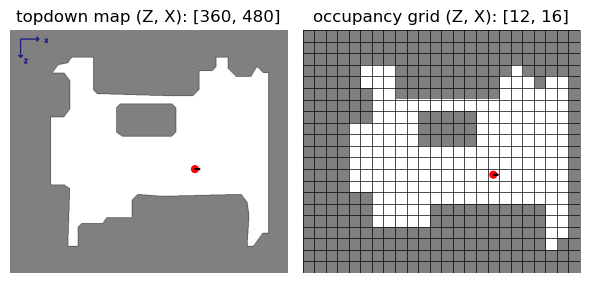


Target object <laptop> found at iter: 64!
Found location: [     1.9052     0.89153    -0.17258]
Real location: [2.0012776851654053, 0.5161712765693665, -0.07372961938381195]


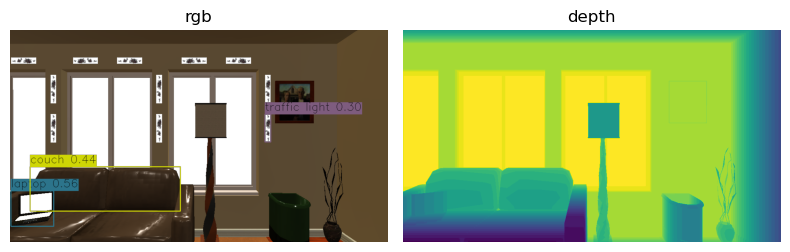

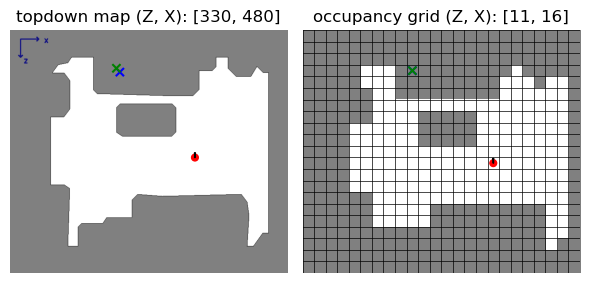

In [6]:
# Main simulation loop
while cur_iter < MAX_ITER:

    # Select an action randomly
    action = random.choice(list(actions))
    num_actions += 1

    # Check if the action is valid
    if not simtools.is_action_valid(action, grid_position, agent_yaw, grid_occ_positions):
        continue 
    
    # Perform the action
    new_grid_position, new_agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)

    # Get new positions
    idx = grid_occ_positions.index(new_grid_position)
    new_map_position = map_occ_positions[idx]
    new_wrld_position = real_wrld_positions[idx]

    # Get quarternion from yaw
    new_agent_quart = myutils.yaw_to_quaternion(new_agent_yaw)

    # Compute travelled distance
    travelled_distance += simtools.compute_travelled_distance(agent_state.position, new_wrld_position)

    # Set agent state
    agent_state.position = new_wrld_position
    agent_state.rotation = new_agent_quart
    agent.set_state(agent_state)

    # Get observations
    observations = sim.get_sensor_observations(0)
    rgb = observations["color_sensor"]
    depth = observations["depth_sensor"]

    # YOLO Prediction
    results = yolo_model.predict(source=rgb[:, :, :3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
    result = results[0]  # One image, one result
    xyxy = result.boxes.xyxy.cpu().numpy()  # (N, 4)
    conf = result.boxes.conf.cpu().numpy()  # (N,)
    cls = result.boxes.cls.cpu().numpy()    # (N,)
    prob_vectors = result.boxes.data[:, 6:].cpu().numpy() # Probability vectors for each class
    names = result.names  # Class names
    
    # Merge results with RGB observations
    simtools.merge_rgb_yolo_outputs(rgb, xyxy, cls, conf, names)

    # Updates
    agent_yaw = new_agent_yaw
    grid_position = new_grid_position
    agent_positions_tpl = (new_map_position, new_grid_position)

    # Check if the target object is found
    OBJECT_FOUND, bbox = simtools.was_object_found(TARGET_OBJECT_ID, cls, conf, xyxy, CONFIDENCE_THRESHOLD)

    # If object is found, compute its real world position
    if OBJECT_FOUND:
        # Get the bounding box of the target object
        x1, y1, x2, y2 = bbox
        center_x = int((x1 + x2) / 2)
        center_y = int((y1 + y2) / 2)
        depth_value = depth[center_y, center_x]

        # Compute the real world position of the target object
        target_object_position = simtools.compute_real_world_position(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, cam_intrcs)

        # Compute the closeness to the target location
        closeness = simtools.compute_closeness(target_object_position, REAL_TARGET_LOCATION)
        break

    # Display the current simulation state (maps + observations)
    if not cur_iter % DISPLAY_STEP:
        print("iter:", cur_iter)
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_maps(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

    # Update step
    cur_iter += 1


# Check if the target object is found
if OBJECT_FOUND:

    # Compute to grid coordinates of the target object coordinates: real and computed
    target_map_position = maps.to_grid(target_object_position[2], target_object_position[0], topdown_resolution, pathfinder=sim.pathfinder)
    target_grid_position = maps.to_grid(target_object_position[2], target_object_position[0], occ_grid_resolution, pathfinder=sim.pathfinder)
    target_2d_coords = (target_map_position, target_grid_position)

    target_real_map_position = maps.to_grid(REAL_TARGET_LOCATION[2], REAL_TARGET_LOCATION[0], topdown_resolution, pathfinder=sim.pathfinder)
    target_real_grid_position = maps.to_grid(REAL_TARGET_LOCATION[2], REAL_TARGET_LOCATION[0], occ_grid_resolution, pathfinder=sim.pathfinder)
    target_real_2d_coords = (target_real_map_position, target_real_grid_position)

    target_coords_tpl = (target_real_2d_coords, target_2d_coords)

    print(f"\nTarget object <{TARGET_OBJECT}> found at iter: {cur_iter}!")
    print(f"Found location: {target_object_position}")
    print(f"Real location: {REAL_TARGET_LOCATION}")
    simtools.display_sim_observations(rgb, depth)
    simtools.display_topdown_maps_with_target(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw, target_coords_tpl)
else:
    print(f"\nTarget object <{TARGET_OBJECT}> not found after {MAX_ITER} iterations!")
    print(f"Real location: [{REAL_TARGET_LOCATION[0]:.3f}, {REAL_TARGET_LOCATION[1]:.3f}, {REAL_TARGET_LOCATION[2]:.3f}]")

In [7]:
# Display simulation metrics
print(f"Number of actions: {num_actions}")
print(f"Travelled distance: {travelled_distance:.2f} m")
print(f"Estimated location error: {closeness:.2f} m")

Number of actions: 73
Travelled distance: 10.82 m
Estimated location error: 0.14 m
